In [1]:
# =====Feature Engineering====
try:
    import missingno as msno
except ImportError:
    print("Installing missingno...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "missingno"])
    import missingno as msno

# Import other libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Loaded Successfully")
# EV PROJECT — DATA PROFILING
# ==========================================

# Install missingno if not already installed
import subprocess
import sys

Libraries Loaded Successfully


In [2]:
# Load cleaned dataset

df = pd.read_csv('D:/Project-04/data/cleaned/ev_cleaned_v1.csv')

print("Cleaned Dataset Loaded")

Cleaned Dataset Loaded


In [3]:
# EV efficiency

df['km_per_kwh'] = np.where(
    df['energy_consumed_kwh'] != 0,
    
    df['distance_km'] / df['energy_consumed_kwh'],
    
    np.nan
)

In [4]:
# Cost per kilometer

df['cost_per_km'] = np.where(
    df['distance_km'] != 0,

    (
        df['electricity_cost_per_kwh']
        * df['energy_consumed_kwh']
    ) / df['distance_km'],

    np.nan
)

In [5]:
# Battery stress score

df['battery_stress_score'] = (
    df['charging_frequency_per_week']
    *
    (100 - df['battery_health_pct'])
)

In [6]:
# Charging dependency score

df['charging_dependency_score'] = np.where(
    df['distance_km'] != 0,
    
    (
        df['charging_frequency_per_week']
        /
        df['distance_km']
    ) * 100,
    
    np.nan
)

In [7]:
# Range utilization percentage

df['range_utilization_pct'] = np.where(
    df['range_km_estimated'] != 0,
    
    (
        df['distance_km']
        /
        df['range_km_estimated']
    ) * 100,
    
    np.nan
)

In [8]:
# Fill km_per_kwh using vehicle type median

df['km_per_kwh'] = df.groupby(
    'vehicle_type_label'
)['km_per_kwh'].transform(
    lambda x: x.fillna(x.median())
)

In [9]:
# Efficiency categories

df['efficiency_category'] = pd.cut(
    df['km_per_kwh'],
    
    bins=[0, 5, 10, 30],
    
    labels=[
        'Low Efficiency',
        'Moderate Efficiency',
        'High Efficiency'
    ]
)

In [10]:
df['efficiency_category'].isnull().sum()

np.int64(20)

In [11]:
# Monthly energy cost estimate

df['monthly_energy_cost'] = (
    df['energy_consumed_kwh']
    *
    df['electricity_cost_per_kwh']
    *
    30
)

In [12]:
# Check missing values in engineered features

engineered_cols = [
    'km_per_kwh',
    'cost_per_km',
    'battery_stress_score',
    'charging_dependency_score',
    'range_utilization_pct',
    'monthly_energy_cost'
]

# First, check which columns actually exist in the DataFrame
existing_cols = [col for col in engineered_cols if col in df.columns]
missing_cols = [col for col in engineered_cols if col not in df.columns]

print(f"Existing columns: {existing_cols}")
print(f"Missing columns: {missing_cols}")

# Check missing values only for existing columns
if existing_cols:
    print("\nMissing values in existing engineered features:")
    print(df[existing_cols].isnull().sum())
else:
    print("None of the engineered columns exist in the DataFrame yet.")

Existing columns: ['km_per_kwh', 'cost_per_km', 'battery_stress_score', 'charging_dependency_score', 'range_utilization_pct', 'monthly_energy_cost']
Missing columns: []

Missing values in existing engineered features:
km_per_kwh                   0
cost_per_km                  0
battery_stress_score         0
charging_dependency_score    0
range_utilization_pct        0
monthly_energy_cost          0
dtype: int64


In [13]:
# Preview engineered features

df.head()

,user_id,city,trip_date,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_duration_min,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,range_anxiety_risk,vehicle_type_label,state,year,month,km_per_kwh,cost_per_km,battery_stress_score,charging_dependency_score,range_utilization_pct,efficiency_category,monthly_energy_cost
0,0f043e7d-c3b7-4478-9566-18494d053204,Mumbai,2026-03-04,2W,3.25,78.31,34.72,2.0,7.0,public_fast,55.32,1.39,6.34,9.27,rainy,0.416,low,17.54,1.0,Two-Wheeler,Maharashtra,2026.0,3.0,5.476341,1.692736,151.83,20.161290,197.947548,Moderate Efficiency,1763.154
1,8507eade-6ee7-4c2d-80b1-eacc566a7cb2,Chennai,2026-08-03,4W,37.14,74.38,1.00,3.0,6.0,home,348.99,3.08,4.16,7.98,extreme_heat,0.266,low,189.43,1.0,Four-Wheeler,Tamil Nadu,2026.0,8.0,0.240385,33.196800,153.72,600.000000,0.527899,Low Efficiency,995.904
2,cad267b4-0561-490e-9d43-46b0530d9359,Hyderabad,2021-08-10,3W,7.46,94.55,7.74,2.0,3.0,public_slow,155.97,0.07,1.21,6.71,rainy,0.092,middle,40.26,0.0,Three-Wheeler,Telangana,2021.0,8.0,6.396694,1.048979,16.35,38.759690,19.225037,Moderate Efficiency,243.573
3,26e25157-b9fe-41ce-8d40-3fa3c0979de5,Delhi,2023-09-15,2W,2.37,93.46,66.67,3.0,5.0,public_fast,64.37,0.88,15.74,8.88,clear,0.251,middle,14.20,1.0,Two-Wheeler,Delhi,2023.0,9.0,4.235705,2.096463,32.70,7.499625,469.507042,Low Efficiency,4193.136
4,9ca94273-0df4-48cb-be60-af643dc606f9,Bangalore,2023-09-28,2W,3.16,86.07,25.27,2.0,4.0,home,361.86,0.80,4.16,8.93,humid,0.166,low,18.97,0.0,Two-Wheeler,Karnataka,2023.0,9.0,6.074519,1.470075,55.72,15.829046,133.210332,Moderate Efficiency,1114.464


In [14]:
# Statistical summary of engineered features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_capacity_kwh,10939.0,11.733338,14.313513,1.130000,3.010000,4.270000,8.850000,55.910000
battery_health_pct,10939.0,89.384754,8.431580,62.060000,83.230000,89.310000,95.520000,116.950000
distance_km,10939.0,26.305385,16.774207,1.000000,15.310000,25.270000,35.335000,187.550000
daily_trip_count,10939.0,2.502514,0.982973,1.000000,2.000000,2.000000,3.000000,6.000000
charging_frequency_per_week,10939.0,3.286224,1.452762,1.000000,2.000000,3.000000,4.000000,8.000000
charging_duration_min,10939.0,179.657059,105.110807,-16.340000,74.860000,178.470000,257.405000,497.270000
charging_station_distance_km,10939.0,1.969730,1.927953,0.000000,0.610000,1.390000,2.680000,17.790000
energy_consumed_kwh,10939.0,4.337997,2.571607,0.110000,2.505000,4.160000,5.960000,19.830000
electricity_cost_per_kwh,10939.0,7.752901,1.505380,2.380000,6.680000,7.760000,8.830000,13.090000
traffic_density,10939.0,0.286272,0.157810,0.000000,0.165000,0.265000,0.389000,0.902000


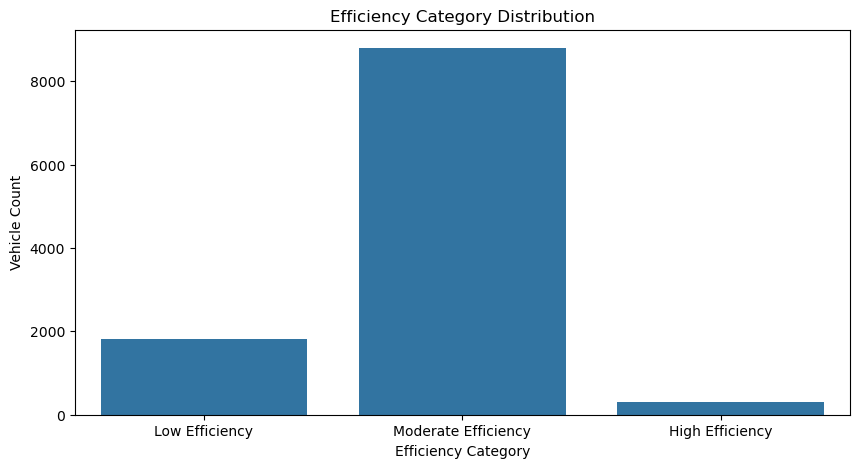

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='efficiency_category',
    data=df
)

plt.title("Efficiency Category Distribution")

plt.xlabel("Efficiency Category")

plt.ylabel("Vehicle Count")

plt.show()

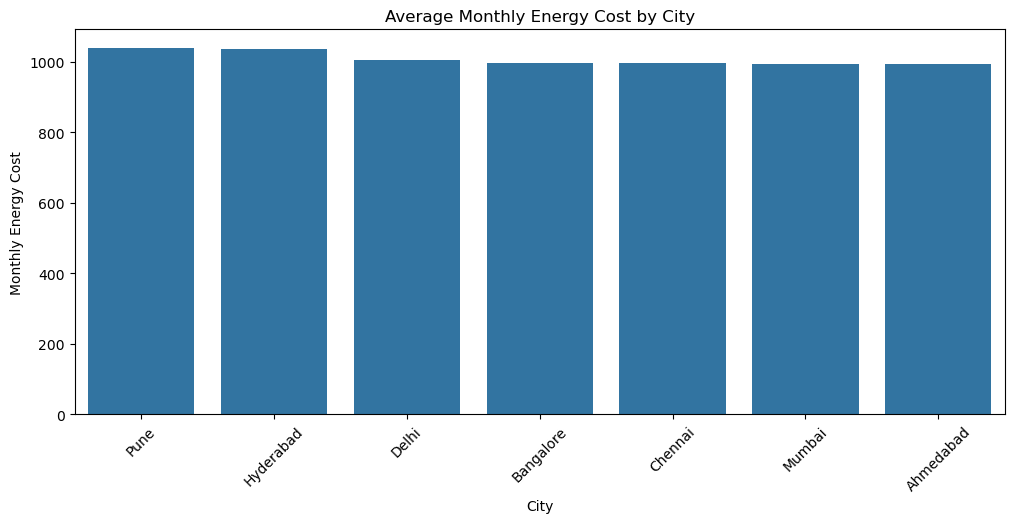

In [16]:
# City-wise monthly energy cost

city_cost = df.groupby(
    'city'
)['monthly_energy_cost'].mean().reset_index()

city_cost = city_cost.sort_values(
    by='monthly_energy_cost',
    ascending=False
)

ordered_cities = city_cost['city']

plt.figure(figsize=(12,5))

sns.barplot(
    data=city_cost,
    x='city',
    y='monthly_energy_cost',
    order=ordered_cities
)

plt.title("Average Monthly Energy Cost by City")

plt.xlabel("City")

plt.ylabel("Monthly Energy Cost")

plt.xticks(rotation=45)

plt.show()

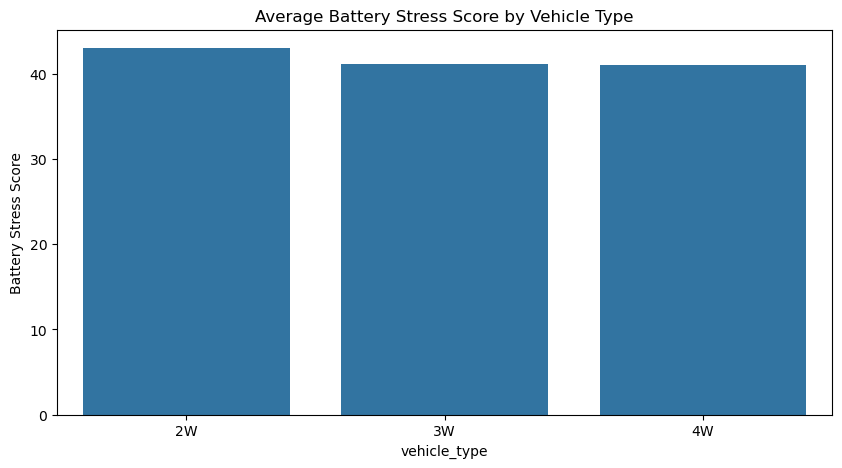

In [17]:
# Average battery stress score by vehicle type

vehicle_stress = df.groupby(
    'vehicle_type'
)['battery_stress_score'].mean().reset_index()

# Sort values

vehicle_stress = vehicle_stress.sort_values(
    by='battery_stress_score',
    ascending=False
)

# Ordered categories

ordered_vehicle = vehicle_stress['vehicle_type']

# Plot

plt.figure(figsize=(10,5))

sns.barplot(
    data=vehicle_stress,
    x='vehicle_type',
    y='battery_stress_score',
    order=ordered_vehicle
)

plt.title("Average Battery Stress Score by Vehicle Type")

plt.xlabel("vehicle_type")

plt.ylabel("Battery Stress Score")

plt.show()

In [18]:
# Save feature engineered dataset

df.to_csv(
    'D:/Project-04/data/cleaned/ev_feature_engineered.csv',
    index=False
)

print("Feature engineered dataset saved successfully")

Feature engineered dataset saved successfully
